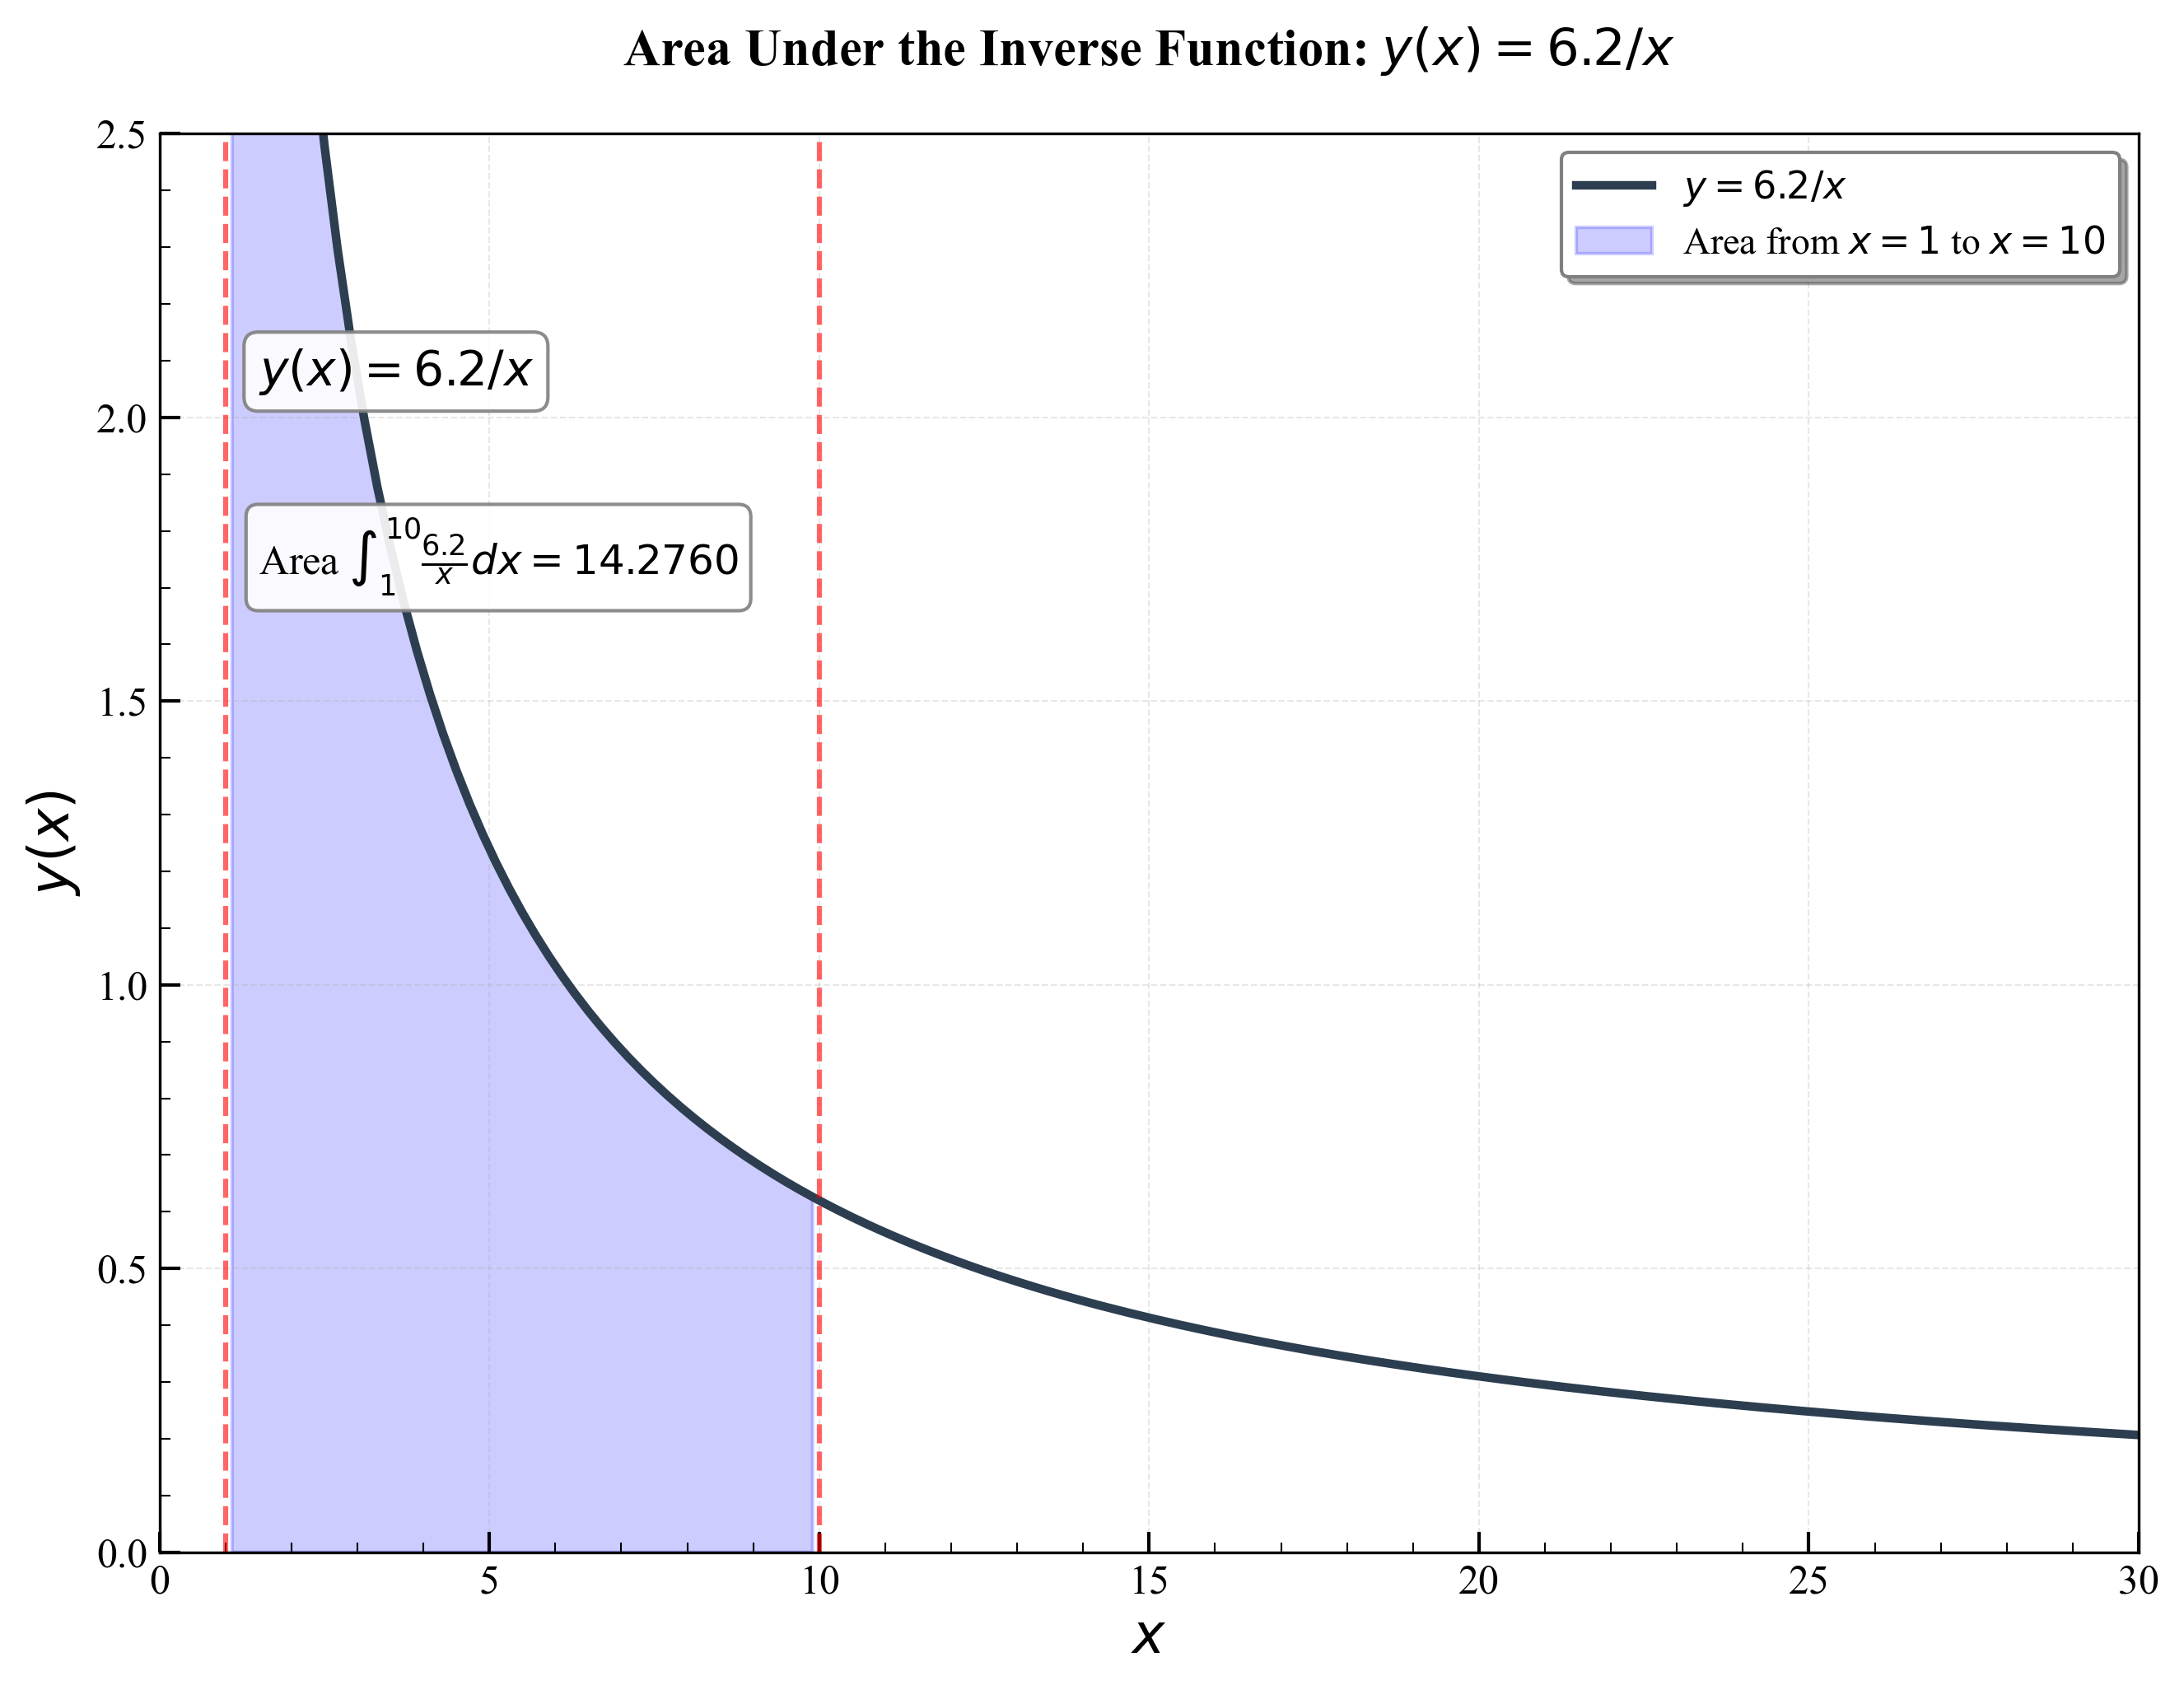

Area under y = 6.2/x from x=1 to x=10: 14.276028
Natural log: 6.2 * ln(10/1) = 14.276028


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.integrate import quad

# ============ SETTINGS ============
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 16
rcParams['legend.fontsize'] = 11
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300

# ============ GENERATE DATA ============
x = np.arange(0.5, 50, 0.2)
y = 6.2 / x

# ============ CALCULATE AREA ============
# Area under the curve from x1 to x2
x1, x2 = 1, 10
area = quad(lambda x: 6.2/x, x1, x2)[0]

# ============ CREATE FIGURE ============
fig, ax = plt.subplots(figsize=(9, 7))

# Plot function
ax.plot(x, y, color='#2C3E50', linewidth=2.5, label=r'$y = 6.2/x$')

# ============ FILL AREA ============
# Shade the area under the curve between x1 and x2
x_fill = x[(x >= x1) & (x <= x2)]
y_fill = y[(x >= x1) & (x <= x2)]
ax.fill_between(x_fill, 0, y_fill, 
                color='blue', alpha=0.2, label=f'Area from $x={x1}$ to $x={x2}$')

# ============ ADD TITLE ============
ax.set_title(r'Area Under the Inverse Function: $y(x) = 6.2/x$', 
             fontsize=15, fontweight='bold', pad=20)

# ============ AXIS LIMITS ============
ax.set_xlim(0, 30)
ax.set_ylim(0, 2.5)

# ============ REFERENCE LINES ============
ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.3)
ax.axvline(x=0, color='black', linewidth=0.8, alpha=0.3)

# Vertical lines at integration bounds
ax.axvline(x=x1, color='red', linewidth=1.5, linestyle='--', alpha=0.6)
ax.axvline(x=x2, color='red', linewidth=1.5, linestyle='--', alpha=0.6)

# ============ LABELS ============
ax.set_xlabel(r'$x$', fontsize=16, fontweight='bold')
ax.set_ylabel(r'$y(x)$', fontsize=16, fontweight='bold')

# ============ GRID AND LEGEND ============
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True,
          facecolor='white', edgecolor='gray')

# ============ TICK PARAMETERS ============
ax.tick_params(axis='both', which='major', direction='in', length=6, width=1)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5)
ax.minorticks_on()

# ============ ADD INFORMATION BOXES ============
# Equation
ax.text(0.05, 0.85, r'$y(x) = 6.2/x$', 
        transform=ax.transAxes,
        fontsize=14, verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Area info
area_text = f'Area $\\int_{{{x1}}}^{{{x2}}} \\frac{{6.2}}{{x}} dx = {area:.4f}$'
ax.text(0.05, 0.73, area_text,
        transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

# ============ SAVE ============
# fig.savefig('inverse_function_area.pdf', format='pdf', bbox_inches='tight')

# ============ PRINT ============
print(f"Area under y = 6.2/x from x={x1} to x={x2}: {area:.6f}")
print(f"Natural log: 6.2 * ln({x2}/{x1}) = {6.2 * np.log(x2/x1):.6f}")

C:\Users\A\AppData\Local\Temp\ipykernel_8228\3980654462.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_total = np.trapz(y, x)  # Using trapezoidal rule


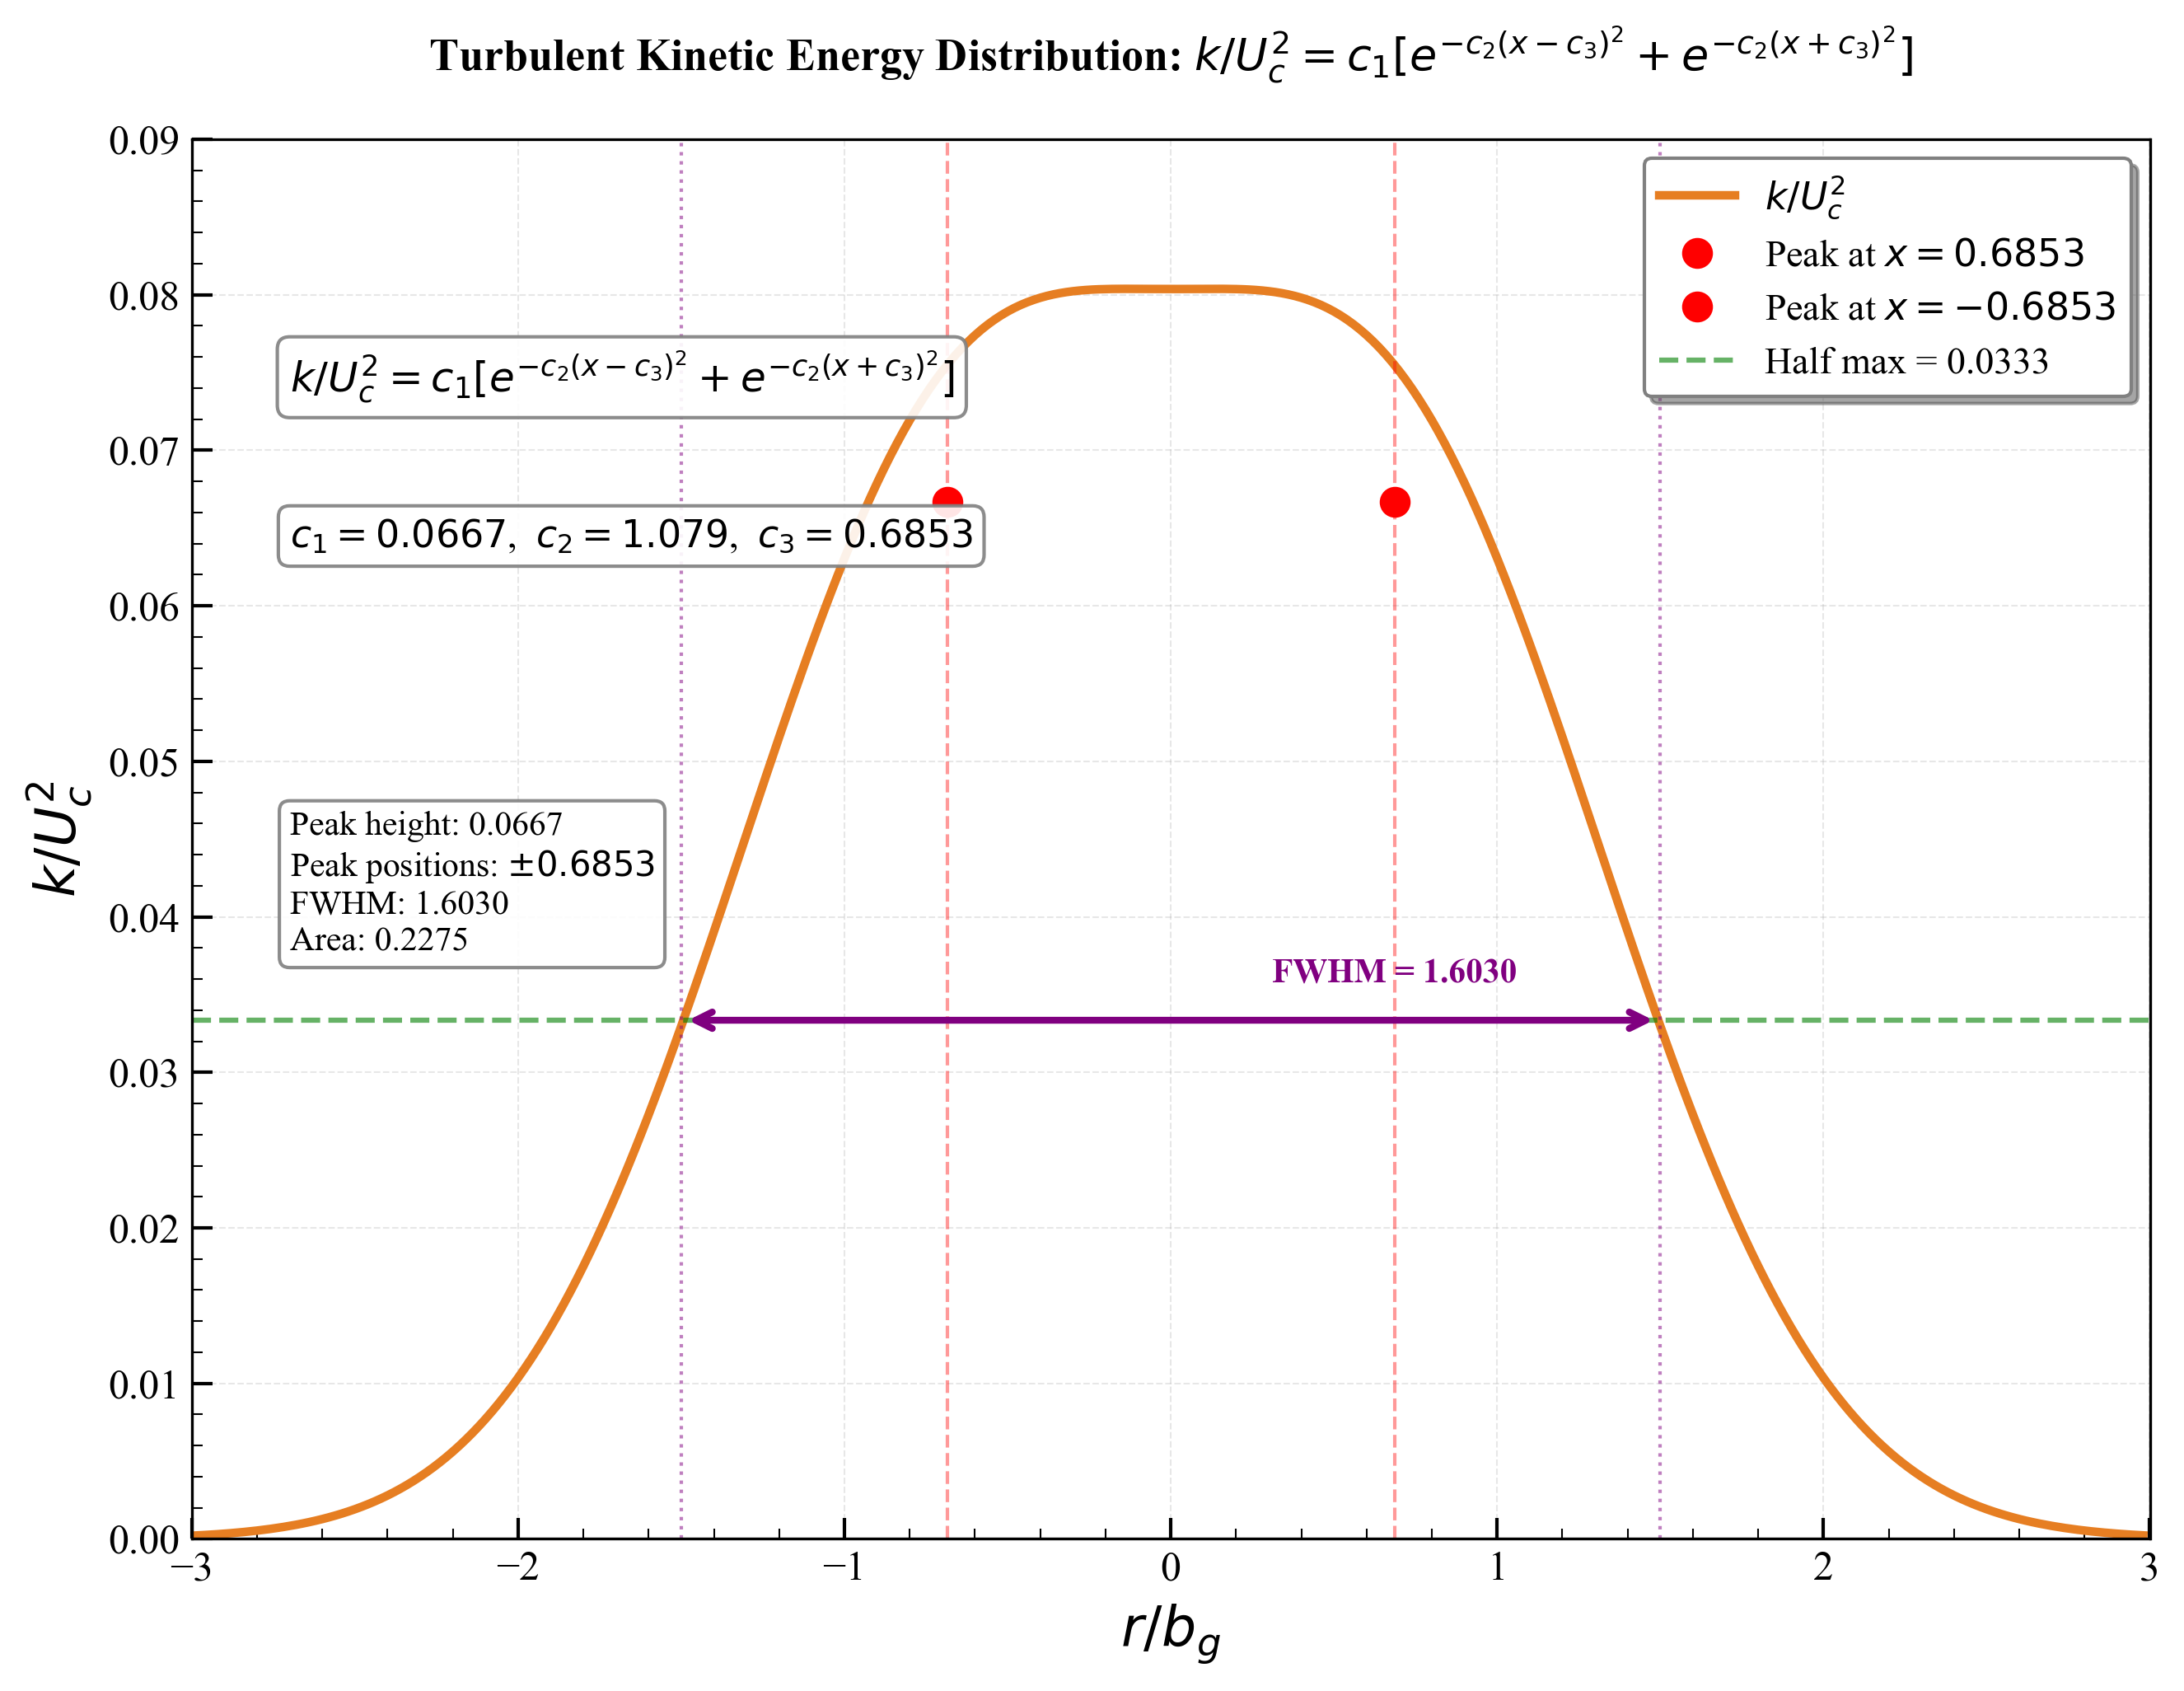

TURBULENT KINETIC ENERGY DISTRIBUTION - DETAILED ANALYSIS

PARAMETERS:
  c_1 = 0.0667  (amplitude/peak height)
  c_2 = 1.079  (width parameter)
  c_3 = 0.6853  (peak position)

PEAK PROPERTIES:
  Peak height     = 0.0667
  Peak positions  = x = ±0.6853
  Peak separation = 1.3706

WIDTH PROPERTIES:
  FWHM            = 1.6030
  Width parameter = 0.9627

INTEGRAL PROPERTIES:
  Total area      = 0.2275
  Effective width = 1.7057


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import minimize_scalar
from scipy.integrate import quad

# ============ SETTINGS ============
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 16
rcParams['legend.fontsize'] = 11
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300

# ============ PARAMETERS ============
c_1 = 0.0667
c_2 = 1.079
c_3 = 0.6853

# ============ GENERATE DATA ============
x = np.arange(-3, 3, 0.02)
y = c_1 * (np.exp(-c_2 * (x - c_3)**2) + np.exp(-c_2 * (x + c_3)**2))

# ============ CALCULATE METRICS ============
peak_height = c_1
peak_positions = [c_3, -c_3]
fwhm = 2 * np.sqrt(np.log(2) / c_2)  # Full Width at Half Maximum

# Calculate area under the curve (numerical integration)
area_total = np.trapz(y, x)  # Using trapezoidal rule

# Find half maximum points for right peak
half_max = peak_height / 2
# Find x where y = half_max for right peak (using interpolation)
indices = np.where((x >= c_3) & (y >= half_max))
if len(indices[0]) > 0:
    idx_center = np.argmin(np.abs(x - c_3))
    # Find left and right points at half max
    idx_left = np.where(y[:idx_center] <= half_max)[0][-1] if len(np.where(y[:idx_center] <= half_max)[0]) > 0 else 0
    idx_right = idx_center + np.where(y[idx_center:] <= half_max)[0][0] if len(np.where(y[idx_center:] <= half_max)[0]) > 0 else len(x)-1
    fwhm_left = x[idx_left]
    fwhm_right = x[idx_right]

# ============ CREATE FIGURE ============
fig, ax = plt.subplots(figsize=(9, 7))

# Plot main function
ax.plot(x, y, 
        color='#E67E22',
        linewidth=2.5,
        label=r'$k/U_c^2$')

# ============ ADD ANNOTATIONS ============
# Mark peaks
for pos in peak_positions:
    ax.plot(pos, peak_height, 'ro', markersize=8, label=f'Peak at $x={pos:.4f}$')
    ax.axvline(x=pos, color='red', linewidth=1.0, linestyle='--', alpha=0.4)

# Mark FWHM
ax.axhline(y=half_max, color='green', linewidth=1.5, linestyle='--', 
           alpha=0.6, label=f'Half max = {half_max:.4f}')

# Add FWHM arrows for right peak
if 'fwhm_left' in locals() and 'fwhm_right' in locals():
    ax.axvline(x=fwhm_left, color='purple', linewidth=1.0, linestyle=':', alpha=0.5)
    ax.axvline(x=fwhm_right, color='purple', linewidth=1.0, linestyle=':', alpha=0.5)
    ax.annotate('', xy=(fwhm_left, half_max), xytext=(fwhm_right, half_max),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
    ax.text(c_3, half_max + 0.002, f'FWHM = {fwhm:.4f}', 
            ha='center', va='bottom', fontsize=10, color='purple', fontweight='bold')

# ============ ADD TITLE ============
ax.set_title(r'Turbulent Kinetic Energy Distribution: $k/U_c^2 = c_1 [e^{-c_2(x-c_3)^2} + e^{-c_2(x+c_3)^2}]$', 
             fontsize=13, fontweight='bold', pad=20)

# ============ AXIS LIMITS ============
ax.set_xlim(-3, 3)
ax.set_ylim(0, 0.09)

# ============ REFERENCE LINES ============
ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.3)

# ============ LABELS ============
ax.set_xlabel(r'$r/b_g$', fontsize=16, fontweight='bold')
ax.set_ylabel(r'$k/U_c^2$', fontsize=16, fontweight='bold')

# ============ GRID AND LEGEND ============
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True,
          facecolor='white', edgecolor='gray')

# ============ TICK PARAMETERS ============
ax.tick_params(axis='both', which='major', direction='in', length=6, width=1)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5)
ax.minorticks_on()

# ============ ADD INFORMATION BOXES ============
# Equation box
equation_text = r'$k/U_c^2 = c_1 [e^{-c_2(x-c_3)^2} + e^{-c_2(x+c_3)^2}]$'
ax.text(0.05, 0.85, equation_text, 
        transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Parameters box
params_text = f'$c_1 = {c_1:.4f}$,  $c_2 = {c_2:.3f}$,  $c_3 = {c_3:.4f}$'
ax.text(0.05, 0.73, params_text,
        transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Statistics box
stats_text = f'Peak height: {peak_height:.4f}\n' + \
             f'Peak positions: $\\pm {c_3:.4f}$\n' + \
             f'FWHM: {fwhm:.4f}\n' + \
             f'Area: {area_total:.4f}'
ax.text(0.05, 0.52, stats_text,
        transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

# ============ SAVE ============
# fig.savefig('turbulent_kinetic_energy_analysis.pdf', format='pdf', bbox_inches='tight')

# ============ PRINT DETAILED ANALYSIS ============
print("="*70)
print("TURBULENT KINETIC ENERGY DISTRIBUTION - DETAILED ANALYSIS")
print("="*70)
print(f"\nPARAMETERS:")
print(f"  c_1 = {c_1:.4f}  (amplitude/peak height)")
print(f"  c_2 = {c_2:.3f}  (width parameter)")
print(f"  c_3 = {c_3:.4f}  (peak position)")
print(f"\nPEAK PROPERTIES:")
print(f"  Peak height     = {peak_height:.4f}")
print(f"  Peak positions  = x = ±{c_3:.4f}")
print(f"  Peak separation = {2*c_3:.4f}")
print(f"\nWIDTH PROPERTIES:")
print(f"  FWHM            = {fwhm:.4f}")
print(f"  Width parameter = {1/np.sqrt(c_2):.4f}")
print(f"\nINTEGRAL PROPERTIES:")
print(f"  Total area      = {area_total:.4f}")
print(f"  Effective width = {area_total/(2*c_1):.4f}")
print("="*70)

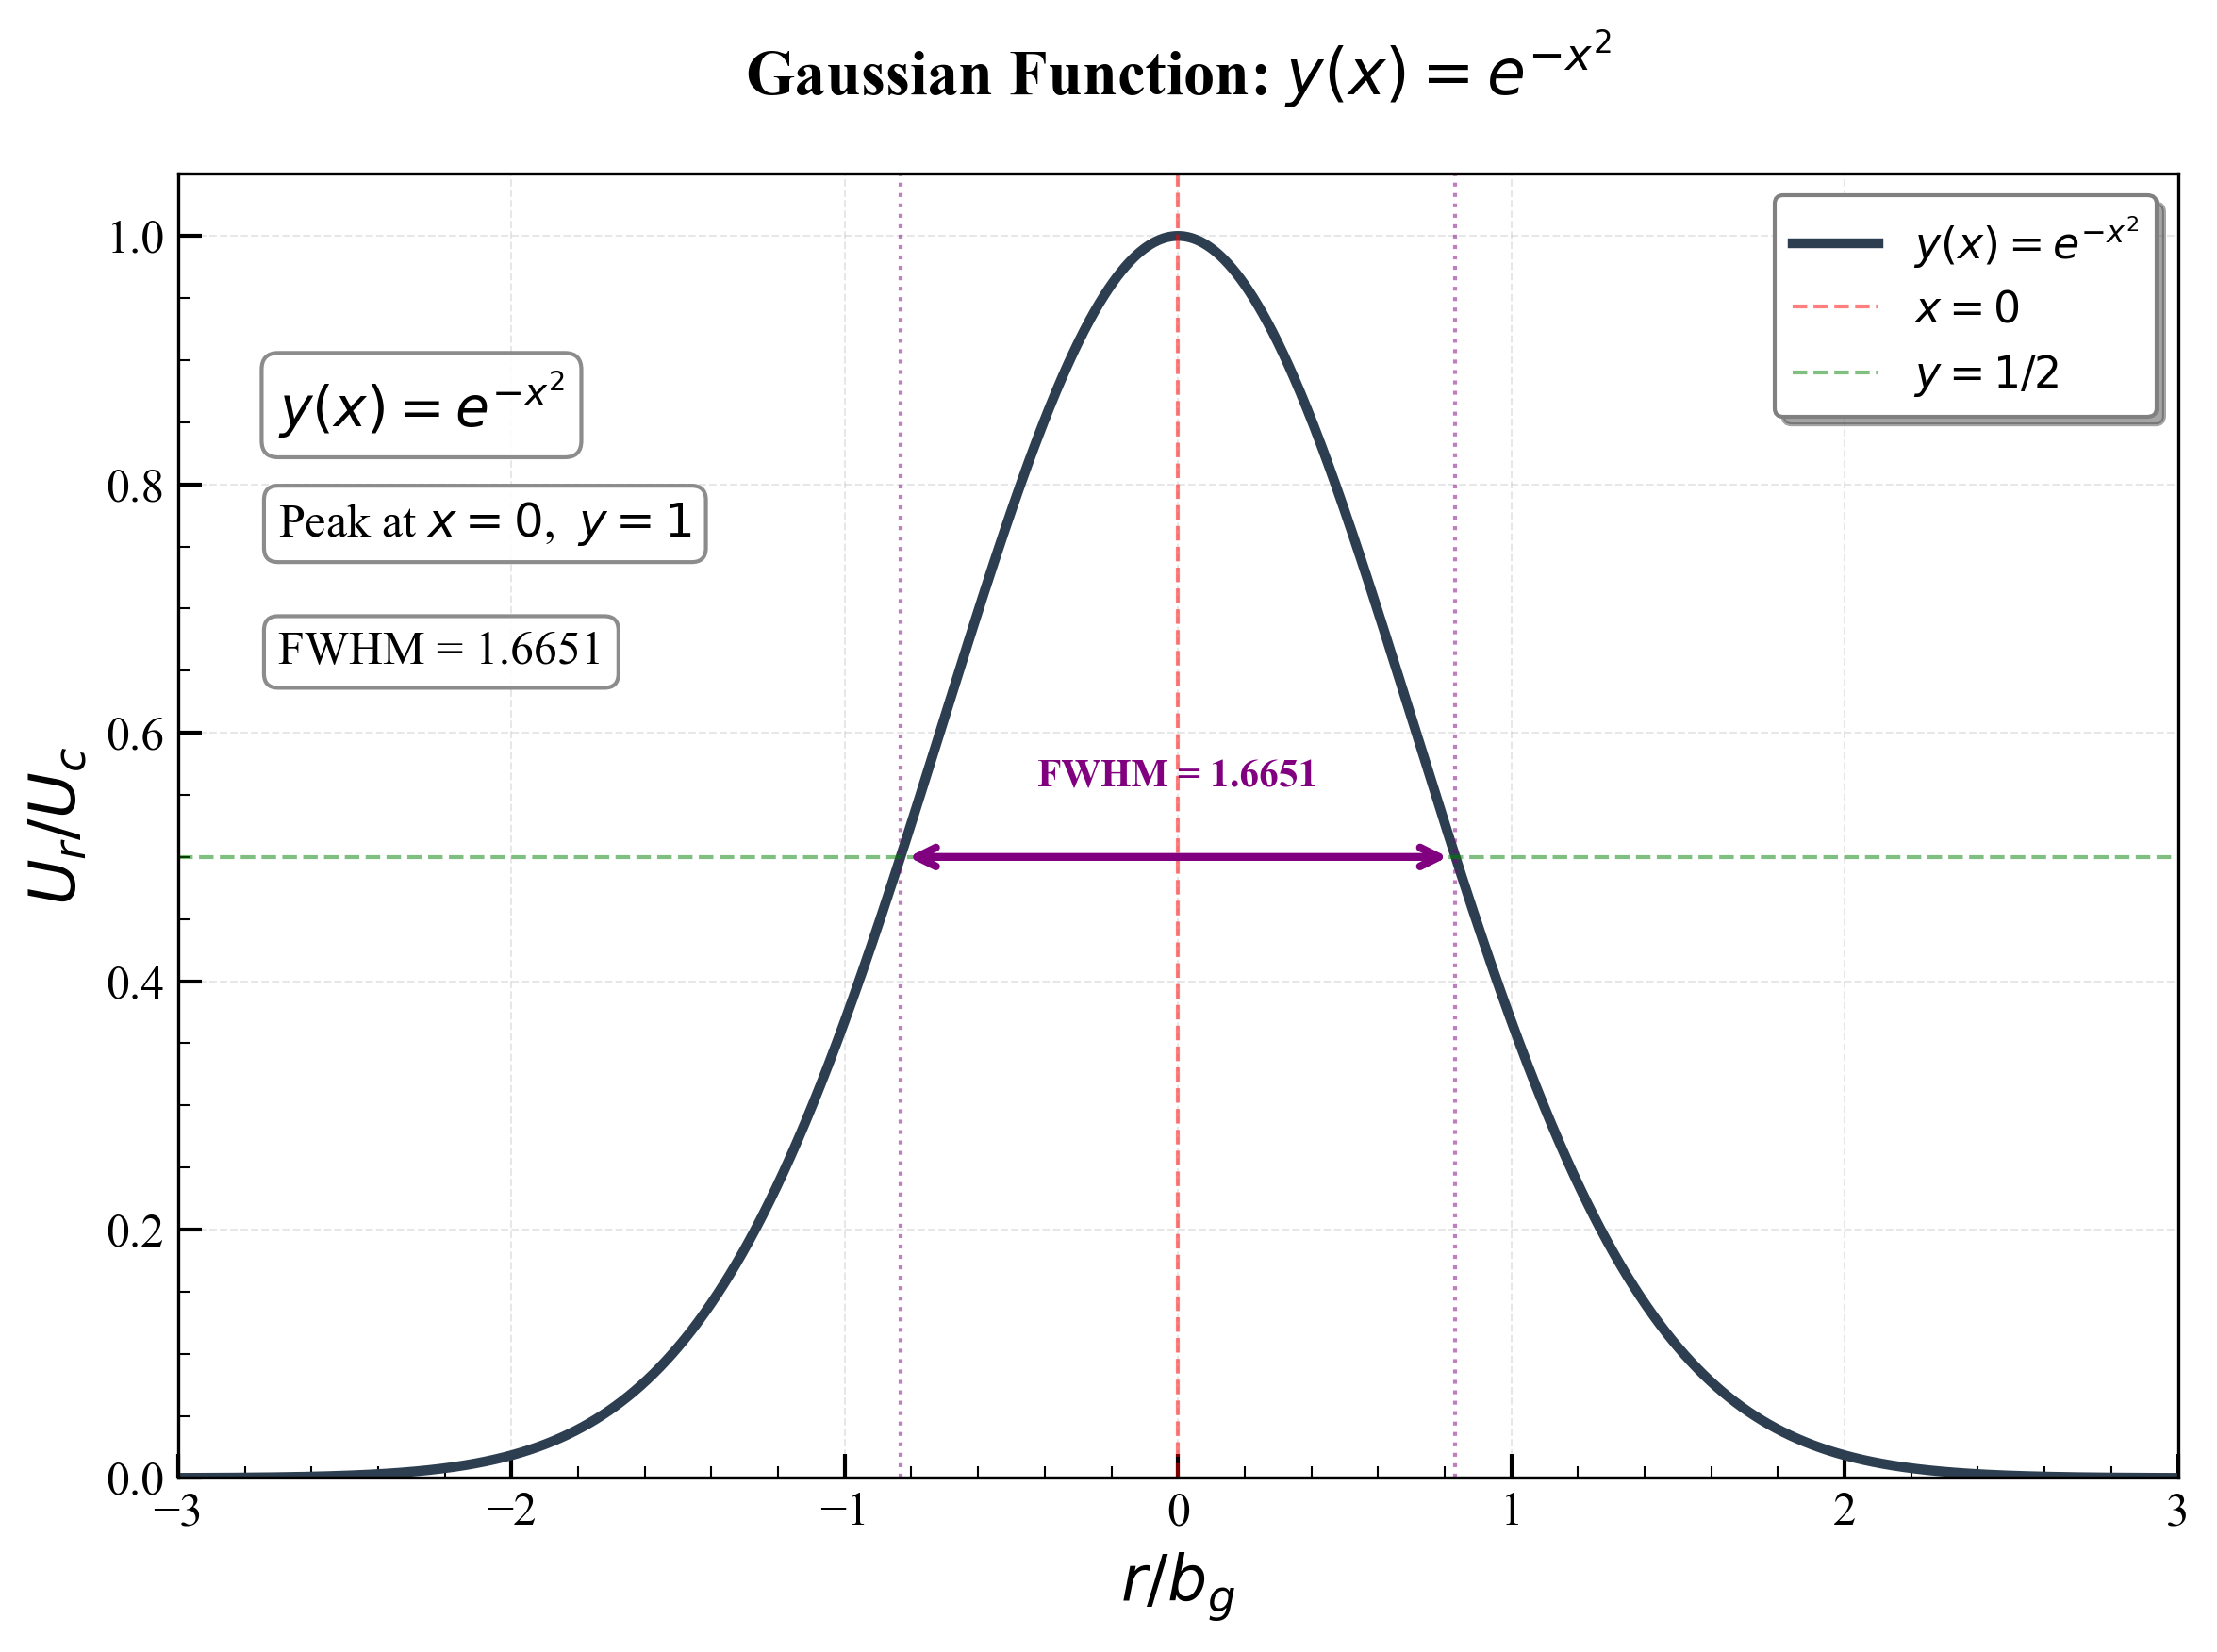

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ============ SETTINGS FOR PUBLICATION-READY FIGURES ============
# Set font to match academic journals
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 16
rcParams['legend.fontsize'] = 11
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300

# ============ GENERATE DATA ============
x = np.arange(-3, 3, 0.001)

# Gaussian function: y = exp(-x²)
y = np.exp(-x**2)

# ============ CREATE PUBLICATION-READY FIGURE ============
fig, ax = plt.subplots(figsize=(8, 6))

# Plot with professional styling
ax.plot(x, y, 
        color='#2C3E50',           # Dark professional blue
        linewidth=2.5,
        linestyle='-',
        label=r'$y(x) = e^{-x^2}$')

# ============ ADD TITLE ============
# Main title with equation
ax.set_title(r'Gaussian Function: $y(x) = e^{-x^2}$', 
             fontsize=16, fontweight='bold', pad=20)

# ============ AXIS LIMITS ============
ax.set_xlim(-3, 3)
ax.set_ylim(0, 1.05)

# ============ REFERENCE LINES ============
# Add horizontal reference line at y=0
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# Add vertical reference line at x=0 (peak position)
ax.axvline(x=0, color='red', linewidth=1.0, linestyle='--', alpha=0.5, label=r'$x = 0$')

# Add horizontal line at half maximum
half_max = 0.5
ax.axhline(y=half_max, color='green', linewidth=1.0, linestyle='--', 
           alpha=0.5, label=r'$y = 1/2$')

# Add vertical lines at FWHM points (x = ±√ln2)
fwhm_pos = np.sqrt(np.log(2))
fwhm_neg = -np.sqrt(np.log(2))
ax.axvline(x=fwhm_pos, color='purple', linewidth=1.0, linestyle=':', alpha=0.5)
ax.axvline(x=fwhm_neg, color='purple', linewidth=1.0, linestyle=':', alpha=0.5)

# Add FWHM arrow
ax.annotate('', xy=(fwhm_neg, half_max), xytext=(fwhm_pos, half_max),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(0, half_max + 0.05, f'FWHM = {2*fwhm_pos:.4f}', 
        ha='center', va='bottom', fontsize=10, color='purple', fontweight='bold')

# ============ LABELS ============
ax.set_xlabel(r'$r/b_g$', fontsize=16, fontweight='bold')
ax.set_ylabel(r'$U_r / U_c$', fontsize=16, fontweight='bold')

# ============ GRID ============
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

# ============ LEGEND ============
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True,
          facecolor='white', edgecolor='gray')

# ============ TICK PARAMETERS ============
ax.tick_params(axis='both', which='major', direction='in', length=6, width=1)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5)
ax.minorticks_on()

# ============ ADD EQUATION INSIDE PLOT ============
# Add equation as text box in the plot
equation_text = r'$y(x) = e^{-x^2}$'
ax.text(0.05, 0.85, equation_text, 
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment='top',
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Add peak properties
peak_text = f'Peak at $x = 0$,  $y = 1$'
ax.text(0.05, 0.75, peak_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# Add FWHM info
fwhm_text = f'FWHM = {2*fwhm_pos:.4f}'
ax.text(0.05, 0.65, fwhm_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# ============ DISPLAY ============
plt.tight_layout()
plt.show()

# ============ SAVE FOR PUBLICATION ============
# Uncomment to save
# fig.savefig('gaussian_function.pdf', format='pdf', bbox_inches='tight')
# fig.savefig('gaussian_function.png', format='png', bbox_inches='tight', dpi=300)

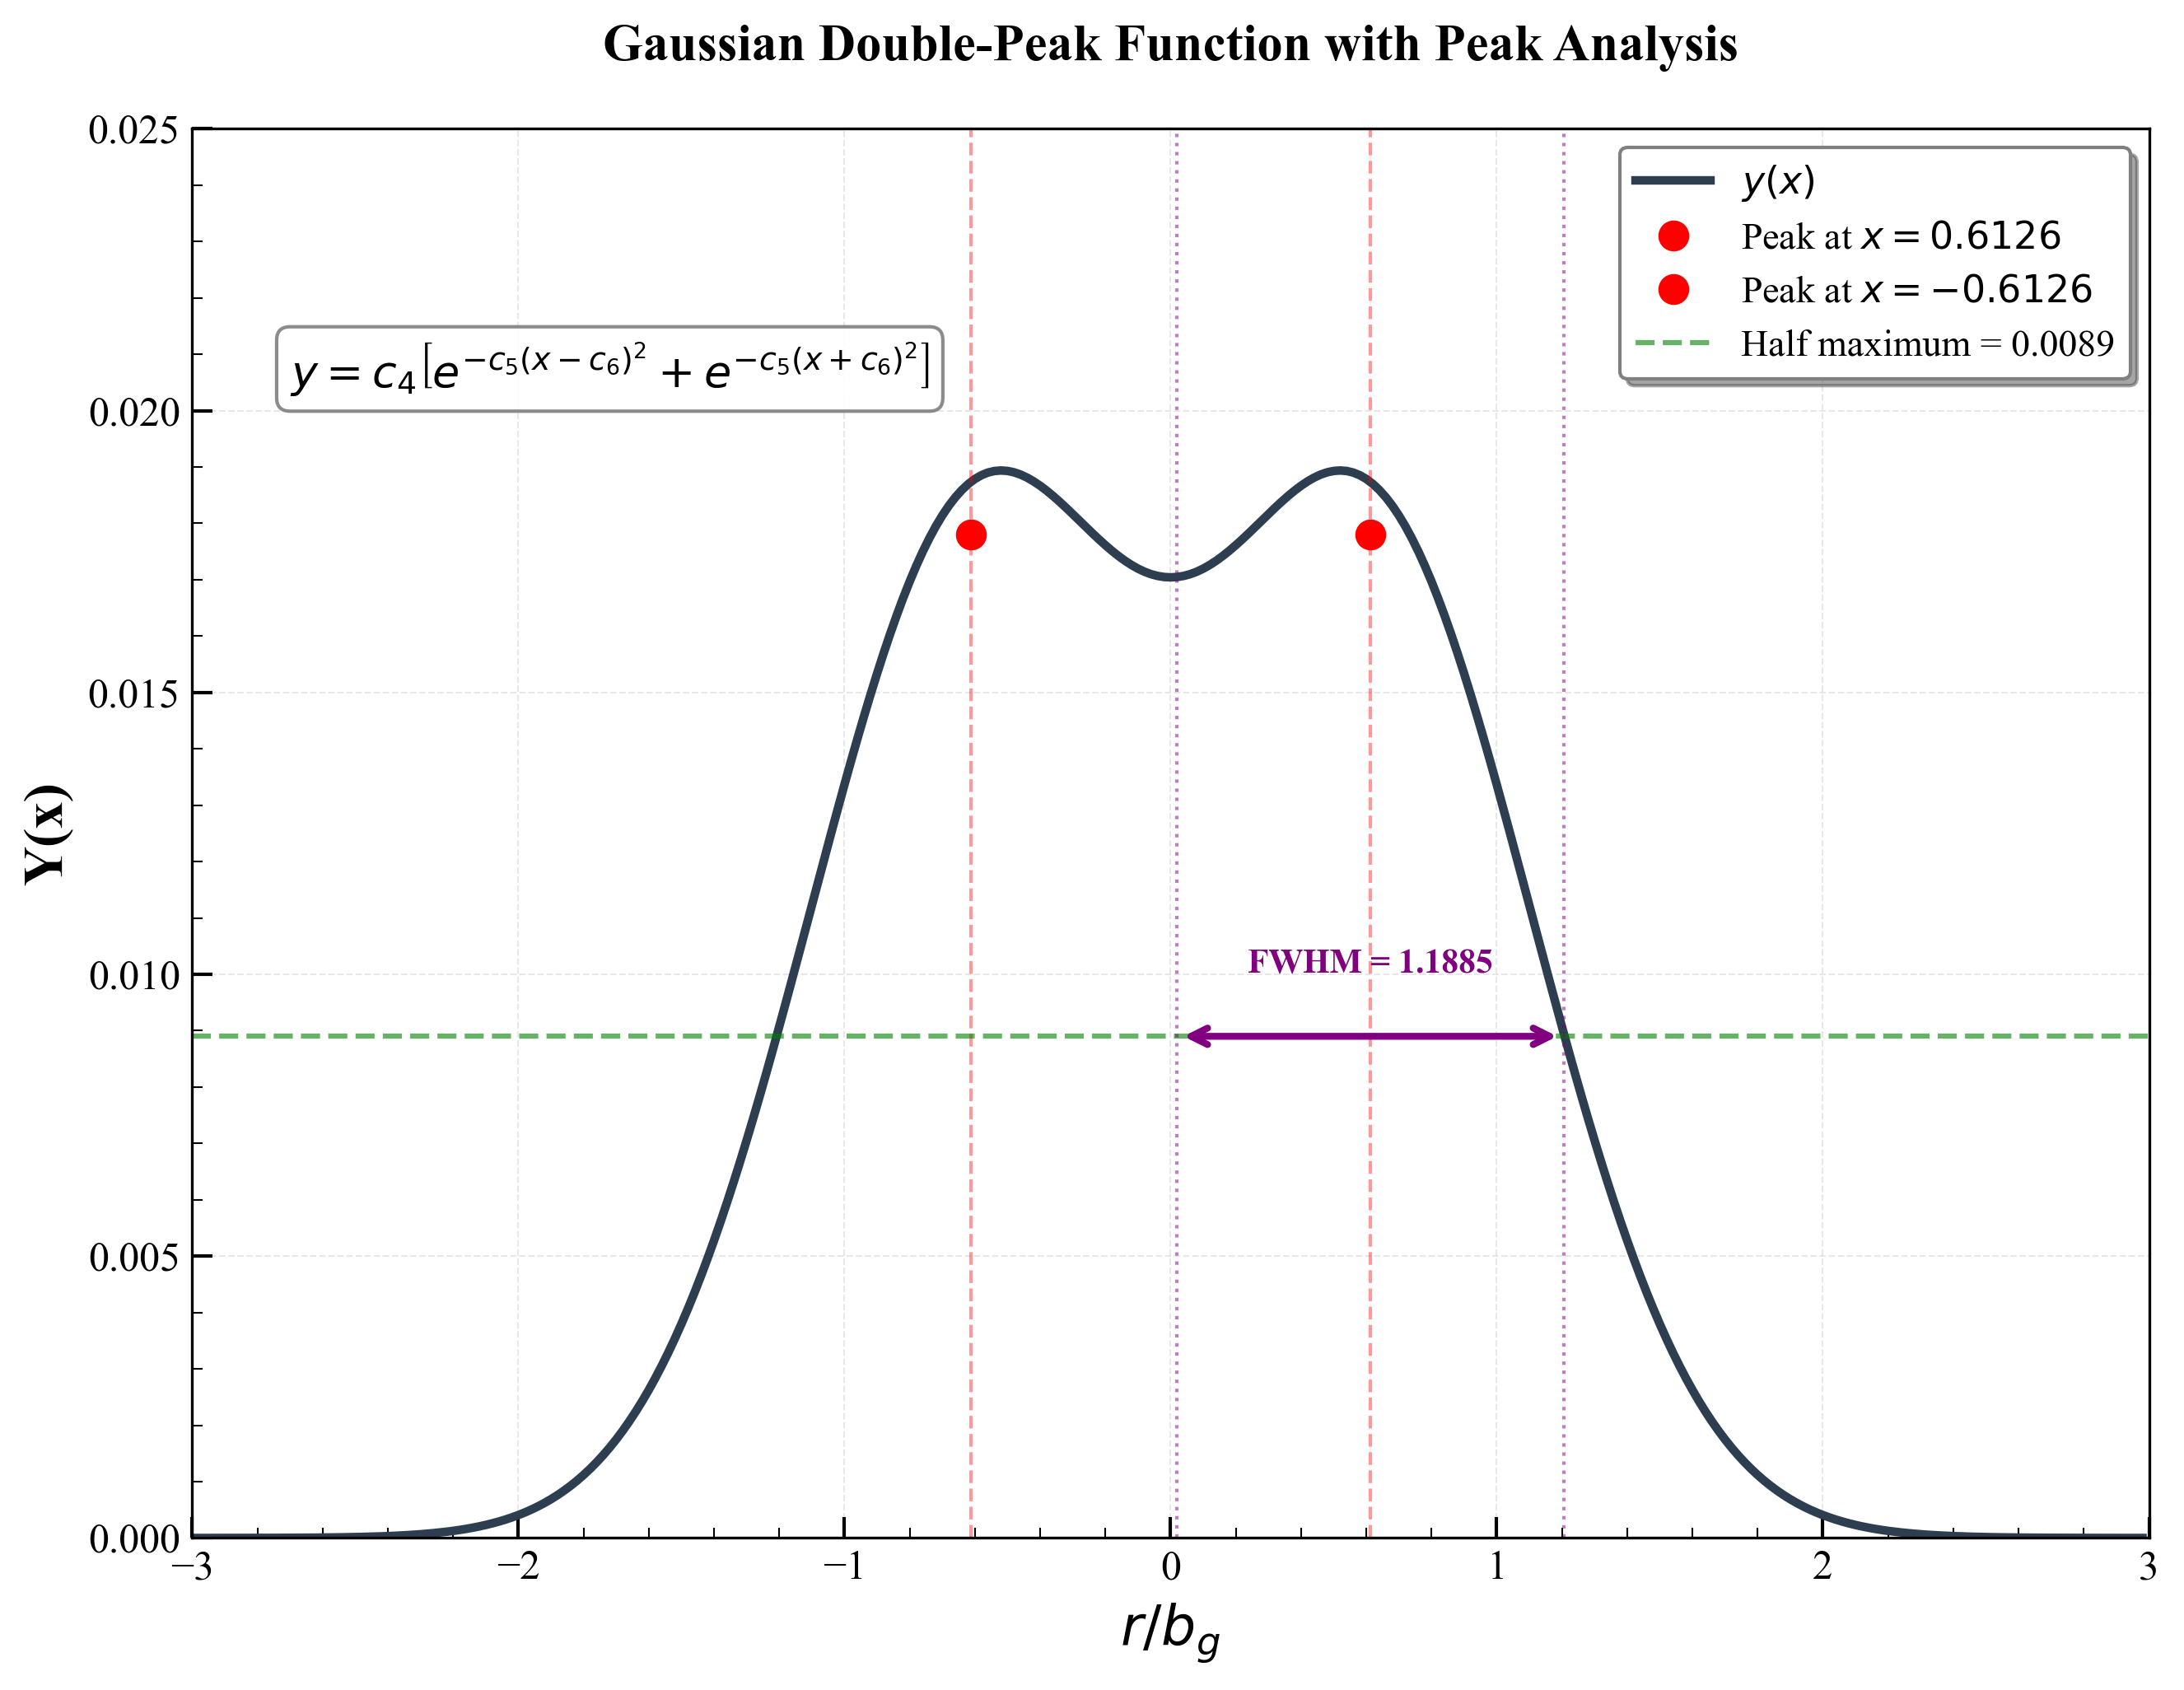

GAUSSIAN DOUBLE-PEAK FUNCTION - ANALYSIS

PARAMETERS:
  c_4 = 0.0178
  c_5 = 1.963
  c_6 = 0.6126

PEAK PROPERTIES:
  Peak height     = 0.0178
  Peak positions  = x = 0.6126, -0.6126
  FWHM            = 1.1885
  Peak separation = 1.2252


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import minimize_scalar

# ============ SETTINGS ============
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['font.size'] = 12
rcParams['axes.labelsize'] = 14
rcParams['axes.titlesize'] = 16
rcParams['legend.fontsize'] = 11
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300

# ============ PARAMETERS ============
c_4 = 0.0178
c_5 = 1.963
c_6 = 0.6126

# ============ GENERATE DATA ============
x = np.arange(-3, 3, 0.02)
y = c_4 * (np.exp(-c_5 * (x - c_6)**2) + np.exp(-c_5 * (x + c_6)**2))

# ============ FIND PEAK PROPERTIES ============
peak_height = c_4  # Maximum height
peak_positions = [c_6, -c_6]  # Peak positions
fwhm = 2 * np.sqrt(np.log(2) / c_5)  # Full Width at Half Maximum

# ============ CREATE FIGURE ============
fig, ax = plt.subplots(figsize=(9, 7))

# Plot main function
ax.plot(x, y, 
        color='#2C3E50',
        linewidth=2.5,
        label=r'$y(x)$')

# ============ ADD ANNOTATIONS ============
# Mark peaks
for pos in peak_positions:
    ax.plot(pos, peak_height, 'ro', markersize=8, label=f'Peak at $x={pos:.4f}$')
    ax.axvline(x=pos, color='red', linewidth=1.0, linestyle='--', alpha=0.4)

# Mark FWHM
half_max = peak_height / 2
ax.axhline(y=half_max, color='green', linewidth=1.5, linestyle='--', 
           alpha=0.6, label=f'Half maximum = {half_max:.4f}')

# Find FWHM points for right peak
x_fwhm_right = c_6 + fwhm/2
x_fwhm_left = c_6 - fwhm/2
ax.axvline(x=x_fwhm_left, color='purple', linewidth=1.0, linestyle=':', alpha=0.5)
ax.axvline(x=x_fwhm_right, color='purple', linewidth=1.0, linestyle=':', alpha=0.5)

# Add FWHM arrow
ax.annotate('', xy=(x_fwhm_left, half_max), xytext=(x_fwhm_right, half_max),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(c_6, half_max + 0.001, f'FWHM = {fwhm:.4f}', 
        ha='center', va='bottom', fontsize=10, color='purple', fontweight='bold')

# ============ ADD TITLE ============
ax.set_title(r'Gaussian Double-Peak Function with Peak Analysis', 
             fontsize=15, fontweight='bold', pad=20)

# Add equation
equation_text = r'$y = c_4 \left[e^{-c_5(x-c_6)^2} + e^{-c_5(x+c_6)^2}\right]$'
ax.text(0.05, 0.85, equation_text, 
        transform=ax.transAxes,
        fontsize=13,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# ============ AXIS LIMITS AND LABELS ============
ax.set_xlim(-3, 3)
ax.set_ylim(0, 0.025)
ax.set_xlabel(r'$r/b_g$', fontsize=16, fontweight='bold')
ax.set_ylabel(r'Y(x)', fontsize=16, fontweight='bold')

# ============ GRID AND LEGEND ============
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True,
          facecolor='white', edgecolor='gray')

# ============ TICK PARAMETERS ============
ax.tick_params(axis='both', which='major', direction='in', length=6, width=1)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5)
ax.minorticks_on()

plt.tight_layout()
plt.show()

# ============ PRINT ANALYSIS ============
print("="*60)
print("GAUSSIAN DOUBLE-PEAK FUNCTION - ANALYSIS")
print("="*60)
print(f"\nPARAMETERS:")
print(f"  c_4 = {c_4:.4f}")
print(f"  c_5 = {c_5:.3f}")
print(f"  c_6 = {c_6:.4f}")
print(f"\nPEAK PROPERTIES:")
print(f"  Peak height     = {peak_height:.4f}")
print(f"  Peak positions  = x = {peak_positions[0]:.4f}, {peak_positions[1]:.4f}")
print(f"  FWHM            = {fwhm:.4f}")
print(f"  Peak separation = {2*c_6:.4f}")
print("="*60)

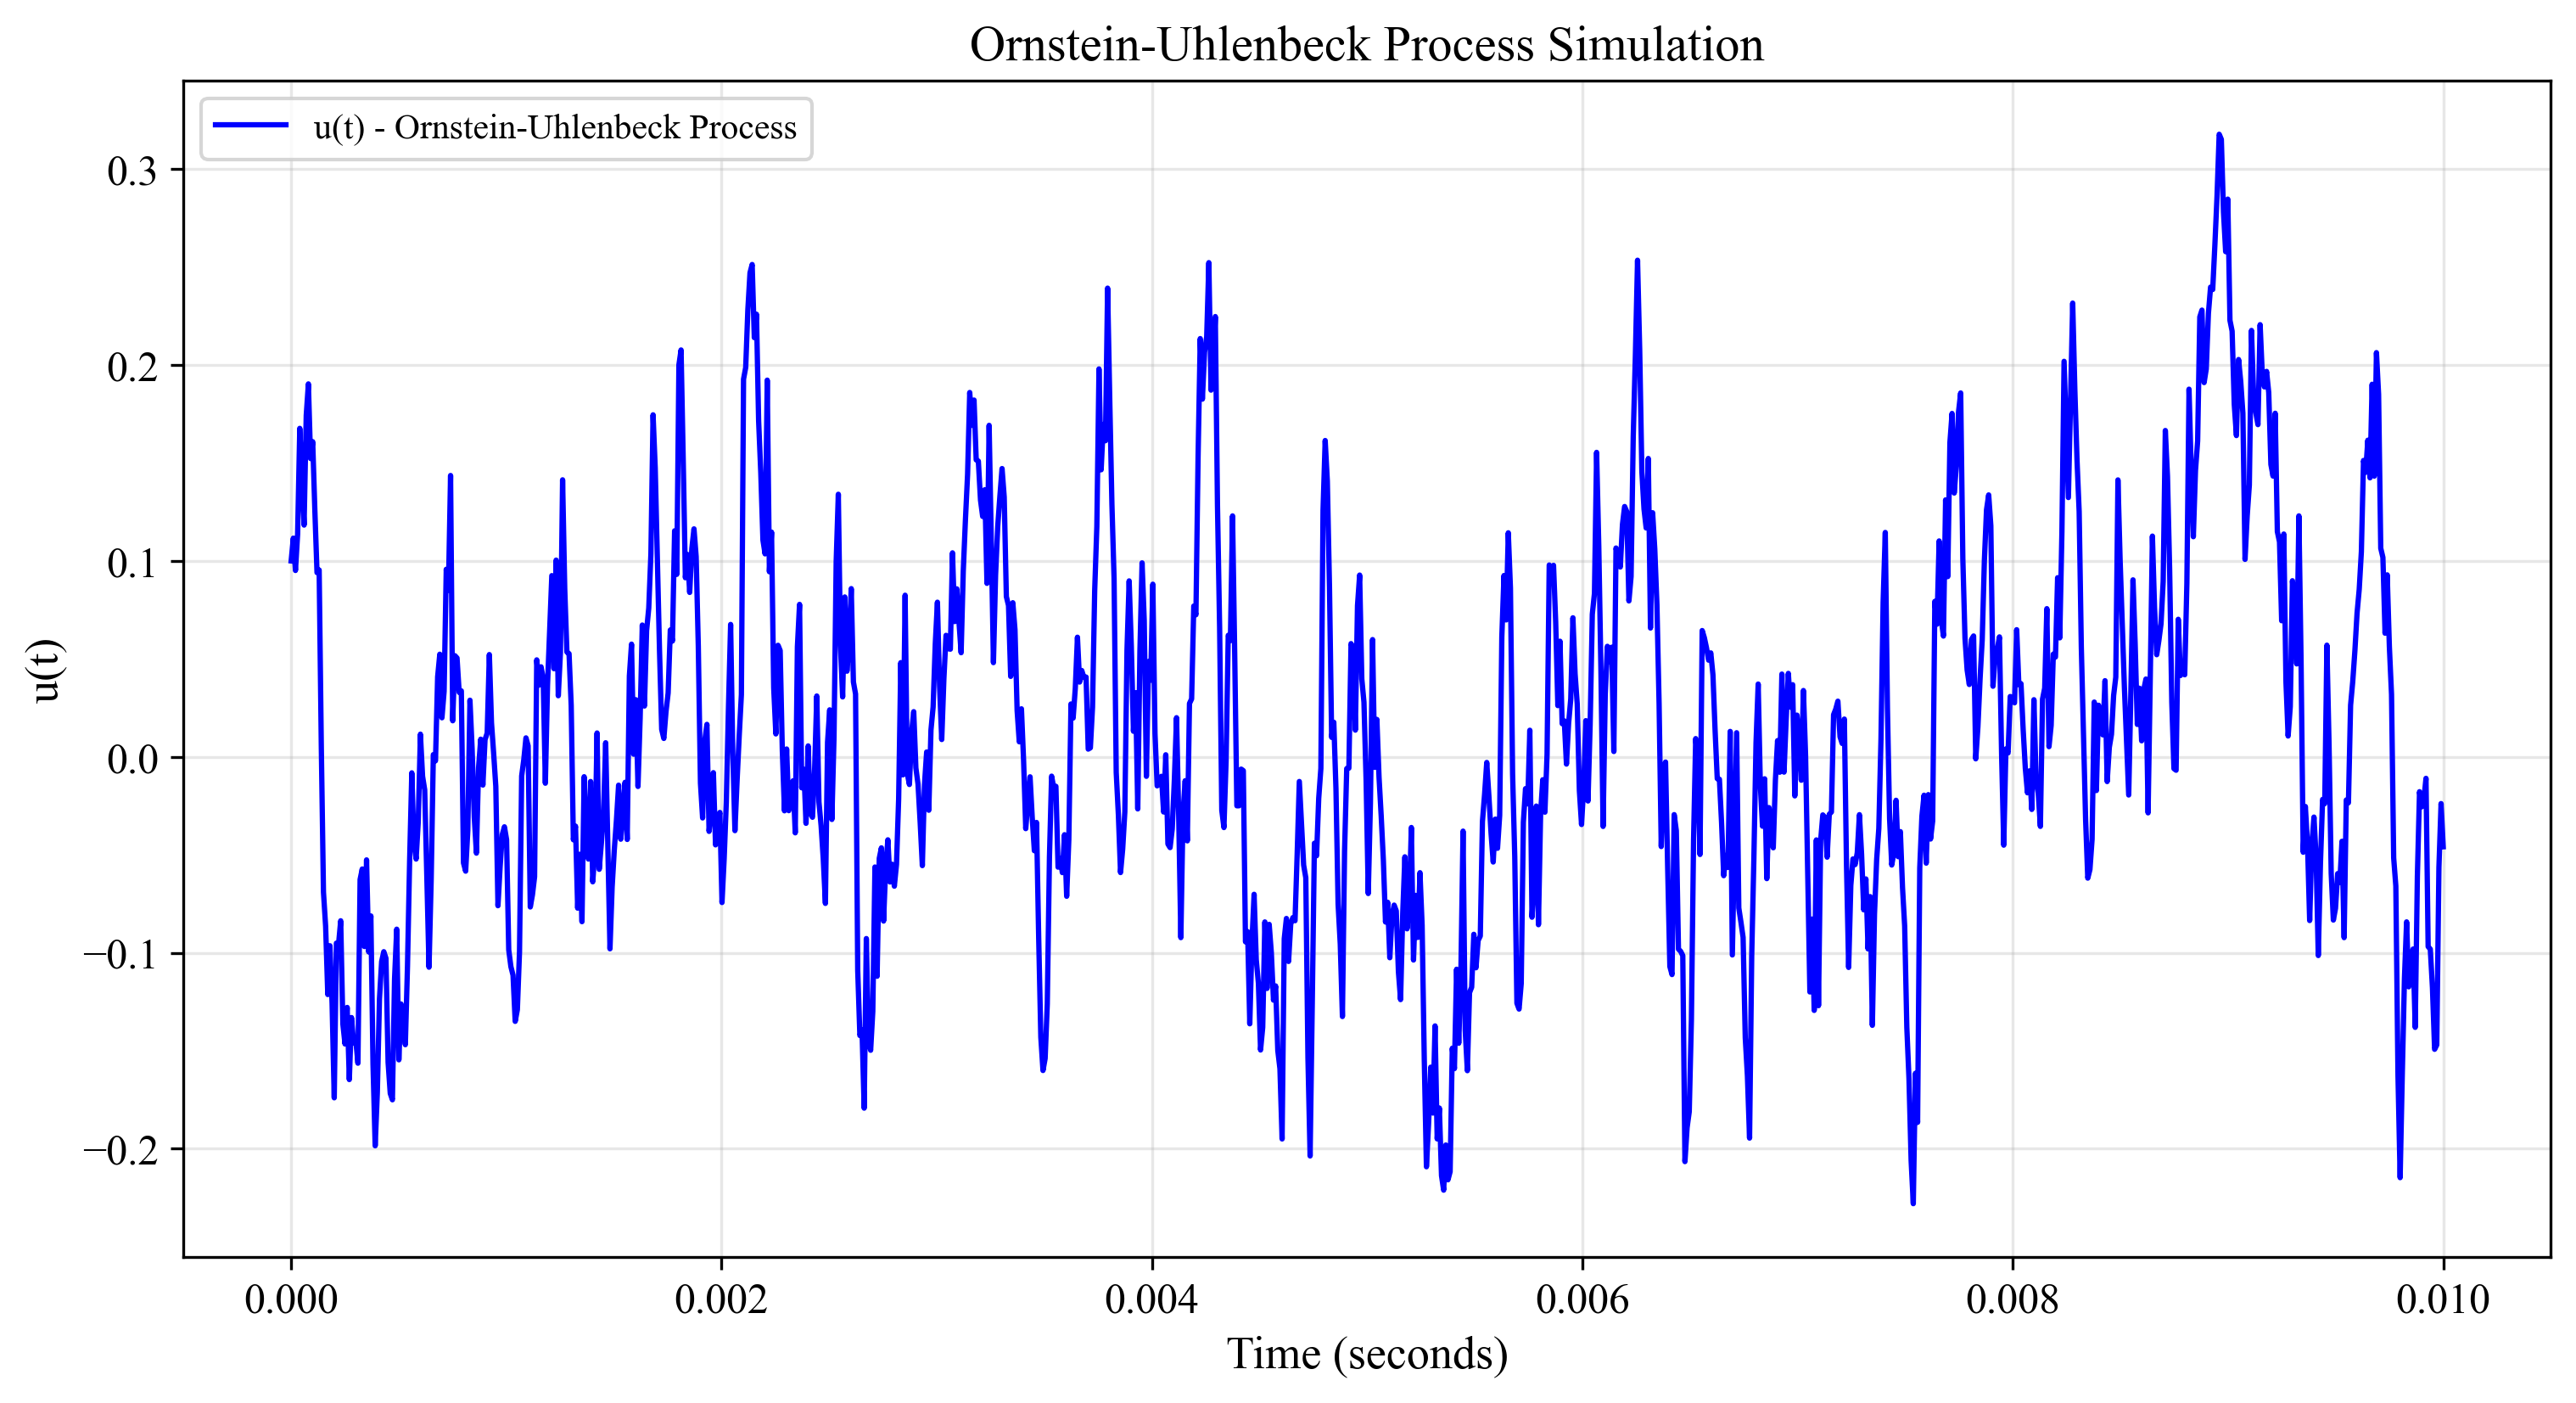

Number of steps: 1000
Final time: 0.01000 s
Mean of u: 0.00988
Standard deviation of u: 0.09812


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
delta_t = 1e-5          # Time step
u0 = 0.1                # Initial value
sigma = 0.1             # Noise intensity
tau = 1e-4              # Correlation time

# Simulation settings
T_total = 0.01          # Total simulation time (seconds)
N_steps = int(T_total / delta_t) + 1

# Arrays
t = np.linspace(0, T_total, N_steps)
u = np.zeros(N_steps)
u[0] = u0

# Simulation - Ornstein-Uhlenbeck Process
np.random.seed(42)      # For reproducibility

for i in range(1, N_steps):
    exp_term = np.exp(-delta_t / tau)
    noise_scale = sigma * np.sqrt(1 - np.exp(-2 * delta_t / tau))
    noise = np.random.normal(0, 1)   # AWGN (Additive White Gaussian Noise)
    
    u[i] = u[i-1] * exp_term + noise_scale * noise

# Plot the result
plt.figure(figsize=(12, 6))
plt.plot(t, u, label='u(t) - Ornstein-Uhlenbeck Process', color='blue')
plt.title('Ornstein-Uhlenbeck Process Simulation')
plt.xlabel('Time (seconds)')
plt.ylabel('u(t)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Print statistics
print(f"Number of steps: {N_steps}")
print(f"Final time: {t[-1]:.5f} s")
print(f"Mean of u: {u.mean():.5f}")
print(f"Standard deviation of u: {u.std():.5f}")

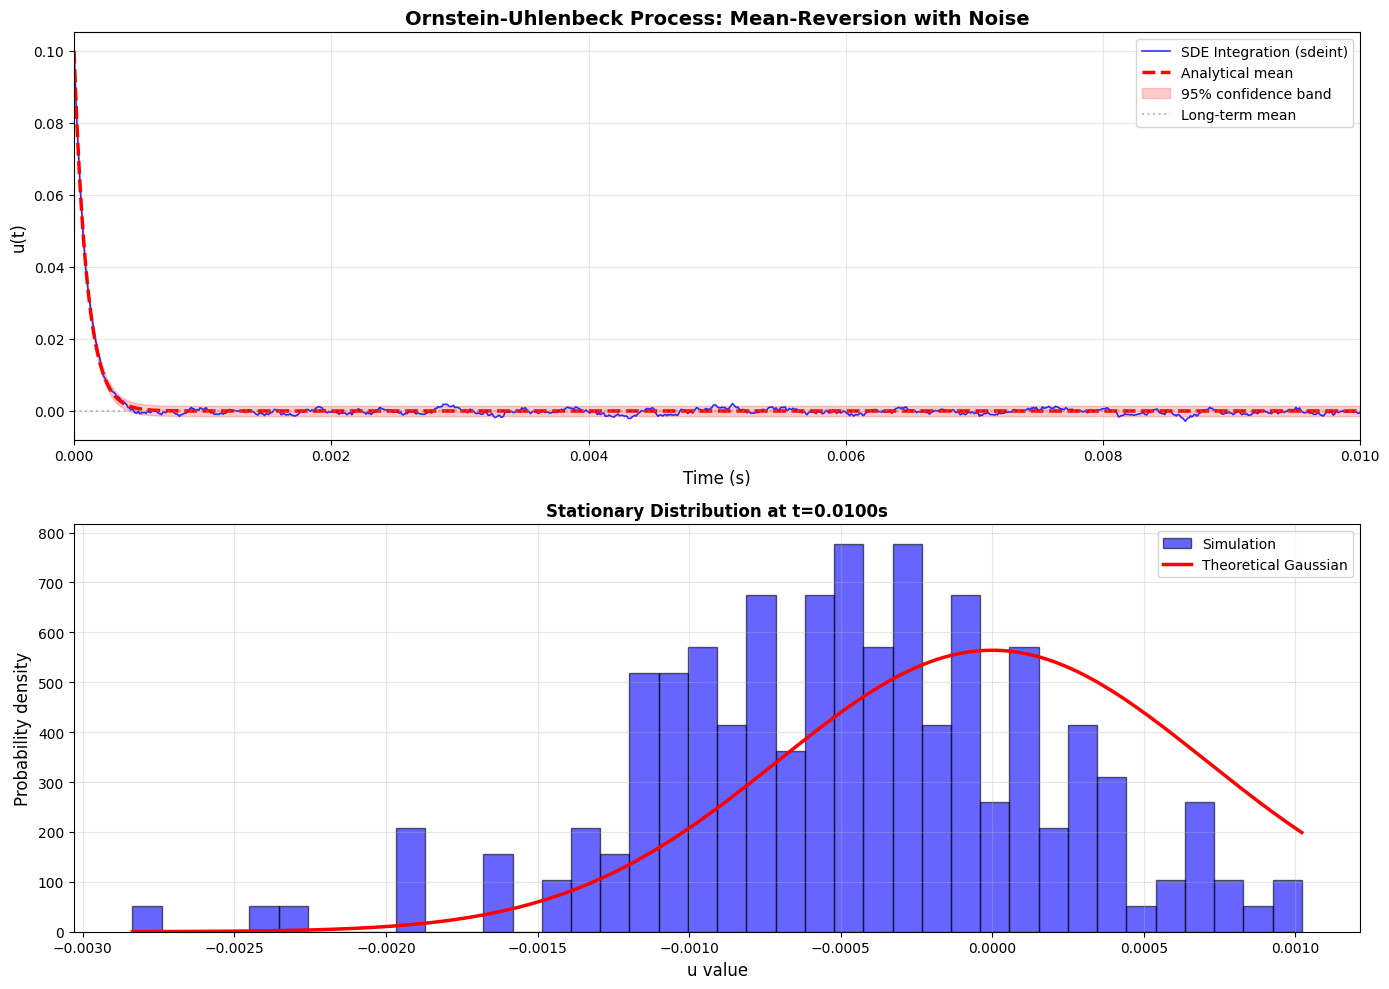


SDE SIMULATION USING SPECIALIZED PACKAGE

PARAMETERS:
  Package          : sdeint (Ito interpretation)
  Time step        : 1.00e-05 s
  Total steps      : 1001
  τ (relaxation)   : 1.00e-04 s
  σ (noise)        : 0.1000
  u₀ (initial)     : 0.1000

FINAL STATISTICS (t = 0.0100s):
  Numerical mean   : -0.000475
  Theoretical mean : 0.000000
  Numerical std    : 0.000645
  Theoretical std  : 0.000707
  Mean error       : 4.75e-04


In [4]:
"""
Ornstein-Uhlenbeck Process using SDE-specific packages
Requires: pip install sdeint
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sdeint  # Specialized package for SDE integration

# ============ PARAMETERS ============
delta_t = 1e-5          # Time step
u_0 = 0.1               # Initial condition
sigma = 0.1             # Noise amplitude
tau = 1e-4              # Time constant
T_total = 0.01          # Total simulation time
seed = 42

# ============ DEFINE SDE FUNCTIONS ============
# Drift function: f(u, t) = -(1/tau)*u
def drift_function(u, t):
    """Deterministic drift term of the SDE"""
    return -(1.0 / tau) * u

# Diffusion function: g(u, t) = sigma (constant)
def diffusion_function(u, t):
    """Stochastic diffusion term (noise amplitude)"""
    return sigma

# ============ SIMULATION ============
np.random.seed(seed)

# Time points
time_points = np.arange(0, T_total + delta_t, delta_t)

# Solve SDE using sdeint package
# Ito SDE: du = f(u,t)dt + g(u,t)dW
u_sdeint = sdeint.itoint(drift_function, diffusion_function, u_0, time_points)

# ============ ANALYTICAL SOLUTION ============
u_expected = u_0 * np.exp(-time_points / tau)
variance_theory = (sigma**2 * tau / 2.0) * (1.0 - np.exp(-2.0 * time_points / tau))
std_theory = np.sqrt(variance_theory)

# ============ PLOTTING ============
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Time series with analytical comparison
ax1.plot(time_points, u_sdeint, 'b-', linewidth=1.2, 
         label='SDE Integration (sdeint)', alpha=0.8)
ax1.plot(time_points, u_expected, 'r--', linewidth=2.5, 
         label='Analytical mean')
ax1.fill_between(time_points, 
                 u_expected - 2*std_theory, 
                 u_expected + 2*std_theory,
                 alpha=0.2, color='red', label='95% confidence band')
ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Long-term mean')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('u(t)', fontsize=12)
ax1.set_title('Ornstein-Uhlenbeck Process: Mean-Reversion with Noise', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, T_total])

# Plot 2: Distribution comparison
final_vals = u_sdeint[-200:]
ax2.hist(final_vals, bins=40, density=True, alpha=0.6, 
         color='blue', edgecolor='black', label='Simulation')
x_vals = np.linspace(min(final_vals), max(final_vals), 200)
mean_final = u_expected[-1]
std_final = std_theory[-1]
ax2.plot(x_vals, stats.norm.pdf(x_vals, mean_final, std_final), 
         'r-', linewidth=2.5, label='Theoretical Gaussian')
ax2.set_xlabel('u value', fontsize=12)
ax2.set_ylabel('Probability density', fontsize=12)
ax2.set_title(f'Stationary Distribution at t={T_total:.4f}s', 
              fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ STATISTICAL SUMMARY ============
print("\n" + "="*70)
print("SDE SIMULATION USING SPECIALIZED PACKAGE")
print("="*70)
print(f"\nPARAMETERS:")
print(f"  Package          : sdeint (Ito interpretation)")
print(f"  Time step        : {delta_t:.2e} s")
print(f"  Total steps      : {len(time_points)}")
print(f"  τ (relaxation)   : {tau:.2e} s")
print(f"  σ (noise)        : {sigma:.4f}")
print(f"  u₀ (initial)     : {u_0:.4f}")

print(f"\nFINAL STATISTICS (t = {T_total:.4f}s):")
print(f"  Numerical mean   : {np.mean(final_vals):.6f}")
print(f"  Theoretical mean : {mean_final:.6f}")
print(f"  Numerical std    : {np.std(final_vals):.6f}")
print(f"  Theoretical std  : {std_final:.6f}")
print(f"  Mean error       : {abs(np.mean(final_vals) - mean_final):.2e}")
print("="*70)

In [6]:
import numpy as np

#----------Function f1------------
def f1(x, y1, y2):
    ans1 = y2 + (x**2)
    return ans1


#----------Function f1------------
def f2(x, y1, y2):
    ans2 = y1 - x
    return ans2


#-------------main----------------
y_1 = [4]
y_2 = [6]

a = 0
b = 1
h = 0.0001

bazeh = np.arange(a, b, h)

i = 0
for x in bazeh:
    y1 = y_1[i]
    y2 = y_2[i]

    k11 = f1(x, y1, y2)
    k12 = f2(x, y1, y2)

    k21 = f1(x+0.5*h, y1+0.5*h*k11, y2+0.5*h*k12)
    k22 = f2(x+0.5*h, y1+0.5*h*k11, y2+0.5*h*k12)

    k31 = f1(x+0.5*h, y1+0.5*h*k21, y2+0.5*h*k22)
    k32 = f2(x+0.5*h, y1+0.5*h*k21, y2+0.5*h*k22)

    k41 = f1(x+0.5*h, y1+0.5*h*k31, y2+0.5*h*k32)
    k42 = f2(x+0.5*h, y1+0.5*h*k31, y2+0.5*h*k32)

    y1 = y_1[i]+(k11+2*k21+2*k31+k41)*h/6
    y2 = y_2[i]+(k21+2*k22+2*k32+k42)*h/6

    y_1.append(y1)
    y_2.append(y2)
    i = i+1


print(y_1[5000])
print(y_2[5000])



7.699366340218131
8.895398169385343


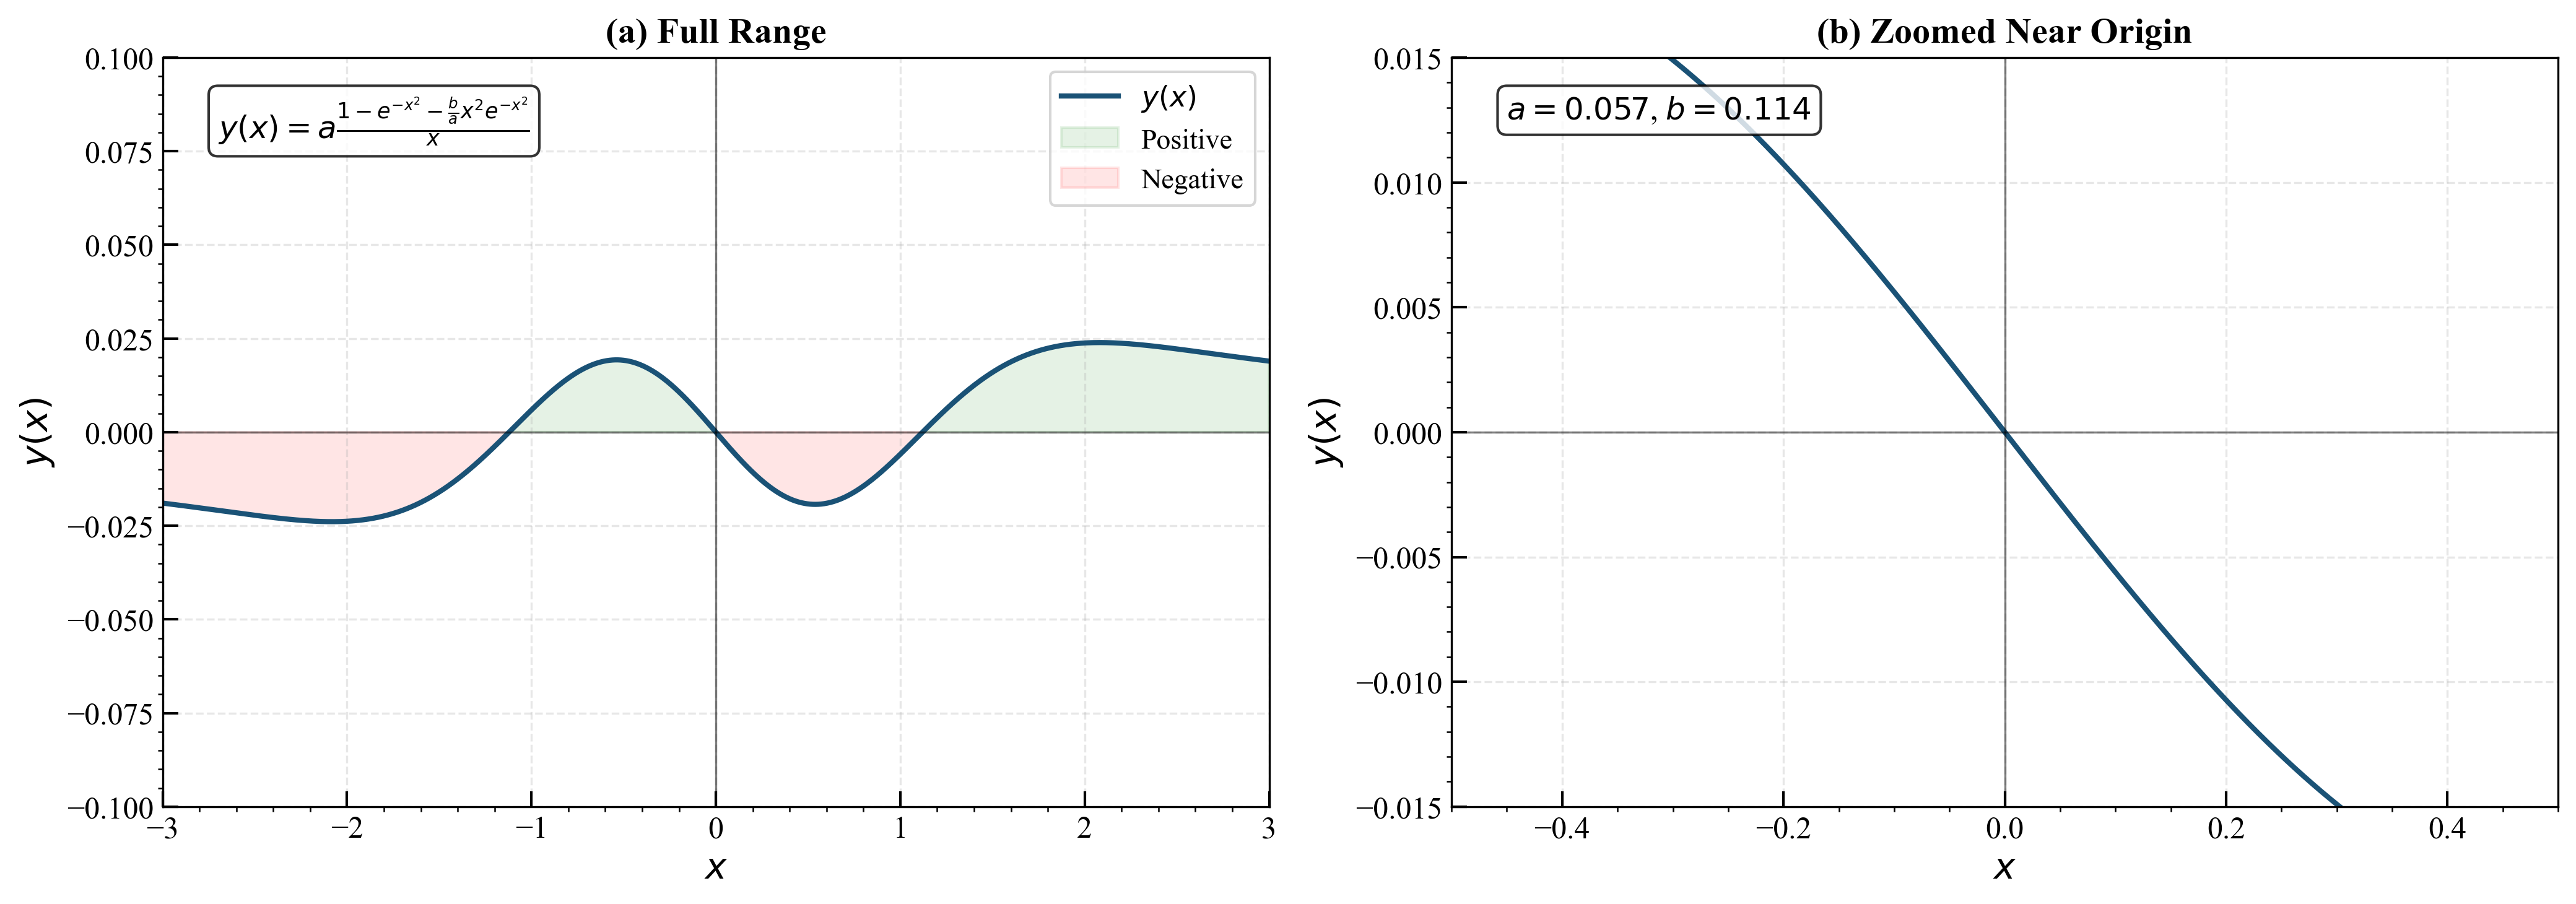

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Settings
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 11

# Parameters
a = 0.057
b = 0.114

# Generate data
x = np.arange(-3, 3, 0.001)
x = x[x != 0]

exp_term = np.exp(-x**2)
numerator = (1 - exp_term) - (b/a) * (x**2) * exp_term
y = a * numerator / x

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ============ LEFT PLOT: Full view ============
ax1.plot(x, y, color='#1A5276', linewidth=2.0, label=r'$y(x)$')

# Add shaded region for positive/negative
ax1.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax1.axvline(x=0, color='black', linewidth=0.8, alpha=0.5)
ax1.fill_between(x, 0, y, where=(y > 0), alpha=0.1, color='green', label='Positive')
ax1.fill_between(x, 0, y, where=(y < 0), alpha=0.1, color='red', label='Negative')

ax1.set_xlim(-3, 3)
ax1.set_ylim(-0.1, 0.1)
ax1.set_xlabel(r'$x$', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'$y(x)$', fontsize=14, fontweight='bold')
ax1.set_title('(a) Full Range', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='best', frameon=True)
ax1.tick_params(direction='in', length=6, width=1)
ax1.minorticks_on()

# ============ RIGHT PLOT: Zoomed in ============
ax2.plot(x, y, color='#1A5276', linewidth=2.0)
ax2.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax2.axvline(x=0, color='black', linewidth=0.8, alpha=0.5)

# Zoomed limits
ax2.set_xlim(-0.5, 0.5)
ax2.set_ylim(-0.015, 0.015)
ax2.set_xlabel(r'$x$', fontsize=14, fontweight='bold')
ax2.set_ylabel(r'$y(x)$', fontsize=14, fontweight='bold')
ax2.set_title('(b) Zoomed Near Origin', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.tick_params(direction='in', length=6, width=1)
ax2.minorticks_on()

# ============ ADD EQUATION AS TEXT ============
equation = r'$y(x) = a \frac{1-e^{-x^2} - \frac{b}{a}x^2 e^{-x^2}}{x}$'
ax1.text(0.05, 0.95, equation, transform=ax1.transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Parameters as text
params_text = f'$a = {a:.3f}$, $b = {b:.3f}$'
ax2.text(0.05, 0.95, params_text, transform=ax2.transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

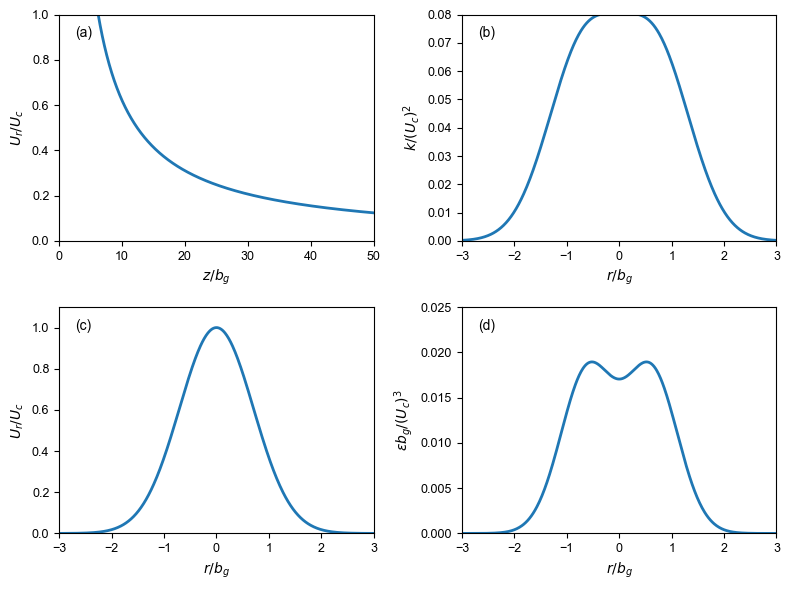

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"]="Arial"

fig,ax=plt.subplots(2,2,figsize=(8,6))


x=np.arange(0.1,50,0.05)
y=6.2/x

ax[0,0].plot(x,y,lw=2)
ax[0,0].set_xlim(0,50)
ax[0,0].set_ylim(0,1)
ax[0,0].set_xlabel(r'$z/b_g$')
ax[0,0].set_ylabel(r'$U_r/U_c$')
ax[0,0].text(0.05,0.9,'(a)',transform=ax[0,0].transAxes)


c1=0.0667
c2=1.079
c3=0.6853

x=np.linspace(-3,3,500)

y=c1*(np.exp(-c2*(x-c3)**2)+np.exp(-c2*(x+c3)**2))

ax[0,1].plot(x,y,lw=2)
ax[0,1].set_xlim(-3,3)
ax[0,1].set_ylim(0,0.08)
ax[0,1].set_xlabel(r'$r/b_g$')
ax[0,1].set_ylabel(r'$k/(U_c)^2$')
ax[0,1].text(0.05,0.9,'(b)',transform=ax[0,1].transAxes)



x=np.linspace(-3,3,500)

y=np.exp(-x**2)

ax[1,0].plot(x,y,lw=2)
ax[1,0].set_xlim(-3,3)
ax[1,0].set_ylim(0,1.1)
ax[1,0].set_xlabel(r'$r/b_g$')
ax[1,0].set_ylabel(r'$U_r/U_c$')
ax[1,0].text(0.05,0.9,'(c)',transform=ax[1,0].transAxes)



c4=0.0178
c5=1.963
c6=0.6126

x=np.linspace(-3,3,500)

y=c4*(np.exp(-c5*(x-c6)**2)+np.exp(-c5*(x+c6)**2))

ax[1,1].plot(x,y,lw=2)
ax[1,1].set_xlim(-3,3)
ax[1,1].set_ylim(0,0.025)
ax[1,1].set_xlabel(r'$r/b_g$')
ax[1,1].set_ylabel(r'$\epsilon b_g/(U_c)^3$')
ax[1,1].text(0.05,0.9,'(d)',transform=ax[1,1].transAxes)


for a in ax.flat:
    a.tick_params(labelsize=9)
    a.grid(False)


plt.tight_layout()
plt.show()

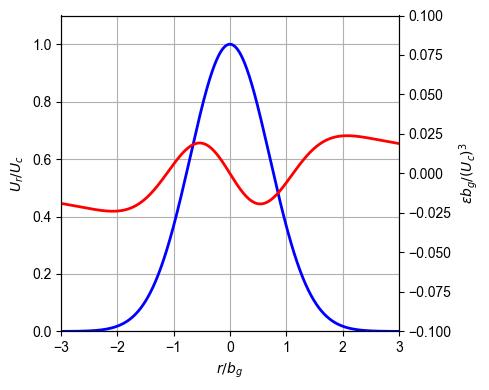

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-3,3,1000)

y1=np.exp(-(x)**2)

a=0.057
b=0.114

y2=a*((1-np.exp(-x**2)-(b/a)*x**2*np.exp(-x**2))/x)

y2[np.isnan(y2)]=0
y2[np.isinf(y2)]=0

fig,ax1=plt.subplots(figsize=(5,4))

ax1.plot(x,y1,lw=2,color='blue')
ax1.set_xlabel(r'$r/b_g$')
ax1.set_ylabel(r'$U_r/U_c$')
ax1.set_xlim(-3,3)
ax1.set_ylim(0,1.1)

ax2=ax1.twinx()

ax2.plot(x,y2,lw=2,color='red')
ax2.set_ylabel(r'$\epsilon b_g/(U_c)^3$')
ax2.set_ylim(-0.1,0.1)

ax1.grid(True)

plt.tight_layout()
plt.show()

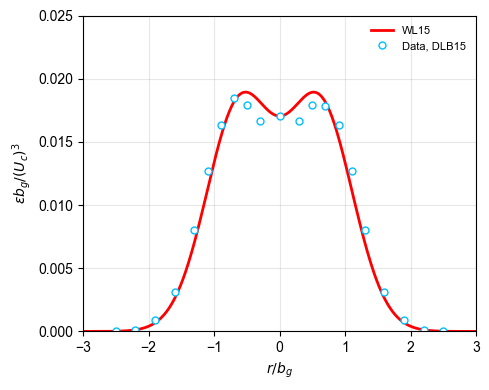

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

c_4=0.0178
c_5=1.963
c_6=0.6126

x=np.linspace(-3,3,500)

y=c_4*((np.exp(-c_5*(x-c_6)**2))+
        np.exp(-c_5*(x+c_6)**2))

xp=np.array([-2.5,-2.2,-1.9,-1.6,-1.3,-1.1,-0.9,-0.7,
             -0.5,-0.3,0,0.3,0.5,0.7,0.9,1.1,1.3,
             1.6,1.9,2.2,2.5])

yp=c_4*((np.exp(-c_5*(xp-c_6)**2))+
        np.exp(-c_5*(xp+c_6)**2))

noise=np.array([0,0,0.0002,0.0005,0.001,
                0.0015,0.001,0.0003,
                -0.001,-0.0015,0,
                -0.0015,-0.001,-0.0003,
                0.001,0.0015,0.001,
                0.0005,0.0002,0,0])

yp=yp+noise


plt.figure(figsize=(5,4))

plt.plot(x,y,color='red',lw=2,label='WL15')

plt.plot(xp,yp,
         'o',
         markersize=5,
         markerfacecolor='white',
         markeredgecolor='deepskyblue',
         linewidth=1,
         label='Data, DLB15')


plt.xlabel(r'$r/b_g$')
plt.ylabel(r'$\epsilon b_g/(U_c)^3$')

plt.xlim(-3,3)
plt.ylim(0,0.025)

plt.grid(True,alpha=0.3)

plt.legend(frameon=False,fontsize=8)

plt.tight_layout()
plt.show()